In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [ ]:
df = pd.read_csv('online_retail.csv', encoding='ISO-8859-1')

In [ ]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:
df.dropna(subset=['CustomerID'], inplace=True)

In [ ]:
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

In [ ]:
df['Revenue'] = df['Quantity'] * df['UnitPrice']

In [ ]:
df = df[df['Revenue'] > 0]

In [ ]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [ ]:
total_revenue = df['Revenue'].sum()
print(total_revenue)

8911407.904


In [ ]:
total_orders = df['InvoiceNo'].nunique()
print(total_orders)

18532


In [ ]:
unique_customers = df['CustomerID'].nunique()
print(unique_customers)

4338


In [ ]:
df['Month'] = df['InvoiceDate'].dt.to_period('M')

monthly_sales = df.groupby('Month')['Revenue'].sum().reset_index()

monthly_sales['Month'] = monthly_sales['Month'].astype(str)

In [ ]:
fig = px.line(monthly_sales,
              x='Month',
              y='Revenue',
              title='Monthly Revenue Trend')

fig.show()

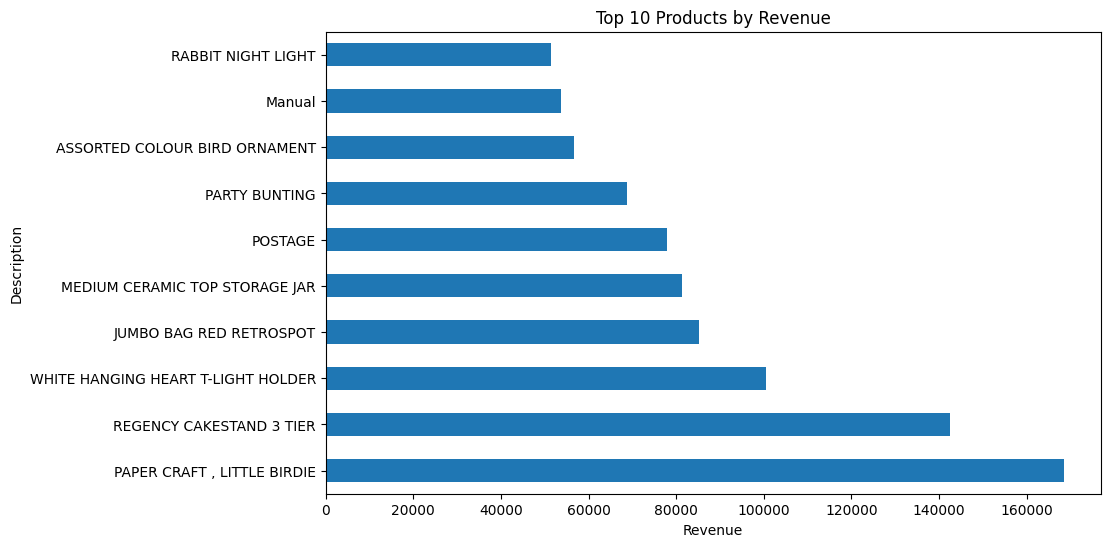

In [ ]:
top_products = df.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10)

top_products.plot(kind='barh', figsize=(10,6))

plt.title('Top 10 Products by Revenue')
plt.xlabel('Revenue')
plt.show()

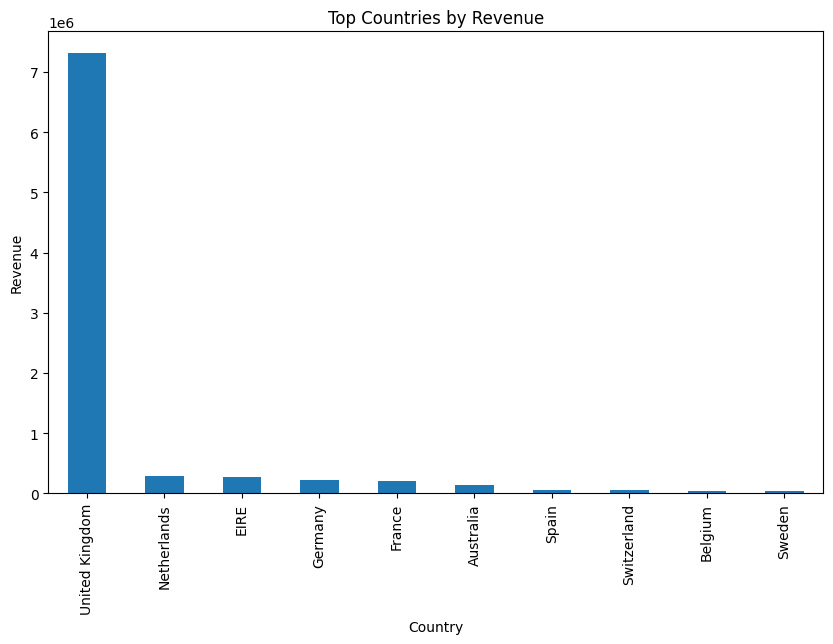

In [ ]:
country_sales = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)

country_sales.plot(kind='bar', figsize=(10,6))

plt.title('Top Countries by Revenue')
plt.ylabel('Revenue')
plt.show()

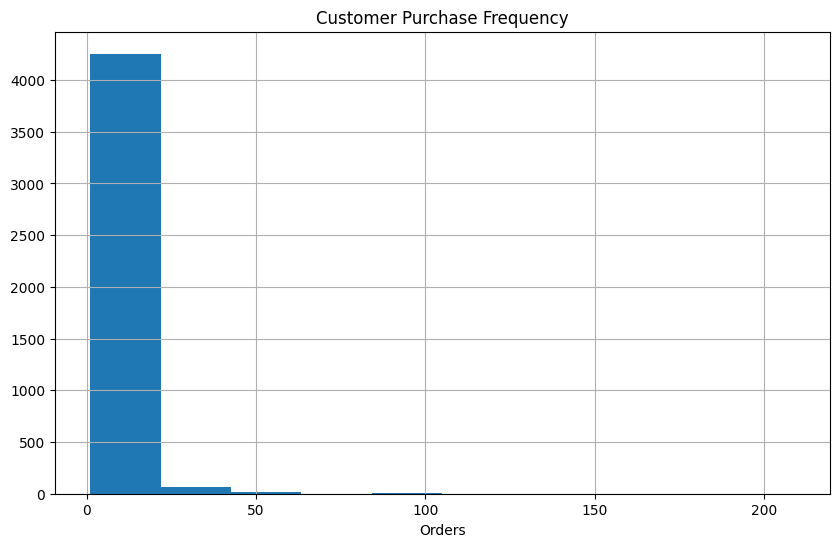

In [ ]:
customer_orders = df.groupby('CustomerID')['InvoiceNo'].nunique()

customer_orders.hist(figsize=(10,6))

plt.title('Customer Purchase Frequency')
plt.xlabel('Orders')
plt.show()

In [ ]:
"""
KEY INSIGHTS

1. Q4 generated highest revenue.
2. UK contributes majority sales.
3. Seasonal spikes occur during holiday months.
4. Certain products dominate revenue generation.
"""

'\nKEY INSIGHTS\n\n1. Q4 generated highest revenue.\n2. UK contributes majority sales.\n3. Seasonal spikes occur during holiday months.\n4. Certain products dominate revenue generation.\n'

In [ ]:
"""
BUSINESS RECOMMENDATIONS

1. Expand international marketing.
2. Increase inventory before Q4.
3. Create loyalty programs for repeat customers.
4. Run promotions during low-sales months.
"""

'\nBUSINESS RECOMMENDATIONS\n\n1. Expand international marketing.\n2. Increase inventory before Q4.\n3. Create loyalty programs for repeat customers.\n4. Run promotions during low-sales months.\n'

In [ ]:
df.to_csv('online_retail_cleaned.csv', index=False)

In [ ]:
fig.write_html("sales_dashboard.html")

In [22]:
from google.colab import files

files.download('online_retail_cleaned.csv')
files.download('sales_dashboard.html')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>